## Notebook Summary
- Data Loading
- Description of the Dataset
- Processing
- EDA

### Import libraries

In [2]:
import os
import pandas as pd
import numpy as np
# Show all columns
pd.set_option('display.max_columns', None)
import warnings

warnings.filterwarnings("ignore")

### Load Metadata

In [3]:
BASE_METADATA_PATH = f"{os.getcwd()}/FungiTastic/metadata/FungiTastic-Mini/"

train_df = pd.read_csv(f"{BASE_METADATA_PATH}FungiTastic-Mini-Train.csv")
val_df = pd.read_csv(f"{BASE_METADATA_PATH}FungiTastic-Mini-ClosedSet-Val.csv")
test_df = pd.read_csv(f"{BASE_METADATA_PATH}FungiTastic-Mini-ClosedSet-Test.csv")

In [4]:
# Metadata Summary
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("val_df shape:", val_df.shape)

train_df shape: (46842, 31)
test_df shape: (10738, 19)
val_df shape: (9412, 31)


### Add images to the Metadata dataframe


In [5]:
BASE_IMAGE_PATH = "./FungiTastic/FungiTastic-Mini"
SIZE = "500p"

train_df["image_path"] = train_df.filename.apply(lambda filename: f"{BASE_IMAGE_PATH}/train/{SIZE}/{filename}")
val_df["image_path"] = val_df.filename.apply(lambda filename: f"{BASE_IMAGE_PATH}/val/{SIZE}/{filename}")
test_df["image_path"] = test_df.filename.apply(lambda filename: f"{BASE_IMAGE_PATH}/val/{SIZE}/{filename}")

In [6]:
# New Summary of the dataframe after loading images
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("val_df shape:", val_df.shape)

train_df shape: (46842, 32)
test_df shape: (10738, 20)
val_df shape: (9412, 32)


### Define Required Columns
Train and Val set must have the selected Label = "species" and some associated columns like "filename" and "image_path" also must be populated. We are dropping rows that are missing these values. We are not dropping rows that maybe missing any other cells values. Dropping all rows blindly with missing cells might lose valuable information. 

In [7]:
LABEL_COL = "species"  # or "category_id" if you prefer IDs
REQUIRED_TRAINVAL = ["filename", "image_path", LABEL_COL]
train_df = train_df.dropna(subset=[c for c in REQUIRED_TRAINVAL if c in train_df.columns]).copy()
val_df   = val_df.dropna(subset=[c for c in REQUIRED_TRAINVAL if c in val_df.columns]).copy()


In [8]:
print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)

train_df shape: (46842, 32)
val_df shape: (9412, 32)


### Removing Leaky Features

In [9]:

def make_nonleaky_dfs(train_df: pd.DataFrame, val_df: pd.DataFrame):
    """
    Returns:
      - train_df_nl, val_df_nl: copies of input DFs with leaky columns removed
      - X_train_meta, y_train: metadata-only features and labels for train
      - X_val_meta,   y_val:   metadata-only features and labels for val
      - kept_feature_cols: ordered list of feature columns actually used
    """
    # --- choose label col once ---
    LABEL_COL = "species" if "species" in train_df.columns else "category_id"
    assert LABEL_COL in train_df.columns and LABEL_COL in val_df.columns, \
        f"Label column '{LABEL_COL}' must exist in both train and val."

    # --- columns that cause target leakage (remove from features) ---
    LEAKY = {
        "species", "category_id", "scientificName", "genus", "family", "order",
        "class", "phylum", "kingdom", "specificEpithet"
    }

    # --- identifiers / non-features (keep in the df for bookkeeping, but not in X) ---
    IDENTIFIERS = {
        "filename", "image_path", "observationID", "eventDate"
    }

    # Work on copies
    train_df_nl = train_df.copy()
    val_df_nl   = val_df.copy()

    # Remove *leaky* columns from both DFs (they can remain in the raw dfs you keep elsewhere)
    drop_cols_train = sorted(LEAKY & set(train_df_nl.columns))
    drop_cols_val   = sorted(LEAKY & set(val_df_nl.columns))
    train_df_nl.drop(columns=drop_cols_train, inplace=True, errors="ignore")
    val_df_nl.drop(  columns=drop_cols_val,   inplace=True, errors="ignore")

    # --- Build feature column list (metadata only, no label, no identifiers) ---
    candidate_cols = [c for c in train_df_nl.columns if c in val_df_nl.columns]
    kept_feature_cols = [
        c for c in candidate_cols
        if c not in LEAKY and c not in IDENTIFIERS and c != LABEL_COL
    ]

    # y (labels)
    y_train = train_df[LABEL_COL].copy()
    y_val   = val_df[LABEL_COL].copy()

    # X (metadata features only)
    X_train_meta = train_df_nl[kept_feature_cols].copy()
    X_val_meta   = val_df_nl[kept_feature_cols].copy()

    # Small report
    print(f"Removed leaky cols (train): {drop_cols_train}")
    print(f"Removed leaky cols (val):   {drop_cols_val}")
    print(f"Features kept ({len(kept_feature_cols)}): {kept_feature_cols}")

    return train_df_nl, val_df_nl, X_train_meta, y_train, X_val_meta, y_val, kept_feature_cols


In [10]:
train_df_nl, val_df_nl, Xtr_meta, ytr, Xva_meta, yva, feat_cols = make_nonleaky_dfs(train_df, val_df)

# Example: quick sanity
assert all(c not in Xtr_meta.columns for c in ["species","category_id","genus","family","order","class","phylum","kingdom","specificEpithet","scientificName"])
assert "image_path" not in Xtr_meta.columns and "filename" not in Xtr_meta.columns
print(Xtr_meta.shape, Xva_meta.shape)


Removed leaky cols (train): ['category_id', 'class', 'family', 'genus', 'kingdom', 'order', 'phylum', 'scientificName', 'species', 'specificEpithet']
Removed leaky cols (val):   ['category_id', 'class', 'family', 'genus', 'kingdom', 'order', 'phylum', 'scientificName', 'species', 'specificEpithet']
Features kept (18): ['year', 'month', 'day', 'habitat', 'countryCode', 'hasCoordinate', 'iucnRedListCategory', 'substrate', 'latitude', 'longitude', 'coorUncert', 'region', 'district', 'metaSubstrate', 'poisonous', 'elevation', 'landcover', 'biogeographicalRegion']
(46842, 18) (9412, 18)


* **`train_df`** — Original Mini-Train metadata + added `image_path`. Contains labels (`species`/`category_id`) and all raw columns (including leaky taxonomy fields).

* **`val_df`** — Original Mini-ClosedSet-Val metadata + `image_path`. Same schema idea as `train_df`; used for validation metrics.

* **`test_df`**  — Mini-ClosedSet-Test metadata + `image_path`. In this copy, **no labels**; good for inference only (no local scoring).

* **`train_df_nl`** — “Non-leaky” copy of `train_df` with taxonomy/label-like columns removed (keeping identifiers like `filename`, `image_path` for bookkeeping).

* **`val_df_nl`** — “Non-leaky” copy of `val_df` with the same columns removed as `train_df_nl`.

* **`Xtr_meta`** — Feature matrix (metadata only) for **train** after selecting non-leaky columns (before/after sklearn transforms, depending on the pipeline step).

* **`ytr`** — Label vector for **train** (`species` or `category_id`).

* **`Xva_meta`** — Feature matrix (metadata only) for **val** aligned with `val_df_nl`.

* **`yva`** — Label vector for **val**.

* **`kept_feature_cols`** *(or `feat_cols`)* — Ordered list of metadata column names actually used to build `Xtr_meta` / `Xva_meta` (i.e., non-leaky, non-identifier features).


-------------
### Save Data Frames for reuse
All dataframes will be saved in the adata_frames dir for consistent use over the different notebooks


In [13]:
from pathlib import Path
import joblib  

# 0) target folder in the current directory
OUT = Path.cwd() / "data_frames"
OUT.mkdir(parents=True, exist_ok=True)

# 1) Save raw-ish splits (with image_path etc.)
train_df.to_parquet(OUT / "train_df.parquet", index=False)
val_df.to_parquet(OUT / "val_df.parquet", index=False)
try:
    test_df.to_parquet(OUT / "test_df.parquet", index=False)
except NameError:
    pass

# 2) Save non-leaky copies
train_df_nl.to_parquet(OUT / "train_df_nl.parquet", index=False)
val_df_nl.to_parquet(OUT / "val_df_nl.parquet", index=False)

# 3) Save metadata features/labels (arrays) + feature names
# (Xtr_meta/Xva_meta are typically numpy arrays; ytr/yva are Series)
np.savez(OUT / "meta_arrays_v1.npz",
         Xtr=Xtr_meta,
         Xva=Xva_meta,
         ytr=np.asarray(ytr),
         yva=np.asarray(yva),
         feat_cols=np.array(feat_cols, dtype=object))



print("Saved to:", OUT)


Saved to: /Users/noshenatashe/Library/Mobile Documents/com~apple~CloudDocs/MIDS/DATASCI_207/fungitastic-classification-datasci207-Fall-2025/baselines/closed_set/data_frames


--------------

In [16]:
# Pretty print with counts
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, f"({df.shape[1]} cols):")
    print(df.columns.tolist(), "\n")

print("Overlaps/Missing Columns: ")


# List column diffs
train_only = sorted(set(train_df.columns) - set(test_df.columns))
test_only  = sorted(set(test_df.columns) - set(train_df.columns))
print("Columns only in TRAIN/VAL:", train_only)
print("Columns only in TEST:", test_only)



train (32 cols):
['eventDate', 'year', 'month', 'day', 'habitat', 'countryCode', 'scientificName', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'specificEpithet', 'hasCoordinate', 'species', 'iucnRedListCategory', 'substrate', 'latitude', 'longitude', 'coorUncert', 'observationID', 'region', 'district', 'filename', 'category_id', 'metaSubstrate', 'poisonous', 'elevation', 'landcover', 'biogeographicalRegion', 'image_path'] 

val (32 cols):
['eventDate', 'year', 'month', 'day', 'habitat', 'countryCode', 'scientificName', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'specificEpithet', 'hasCoordinate', 'species', 'iucnRedListCategory', 'substrate', 'latitude', 'longitude', 'coorUncert', 'observationID', 'region', 'district', 'filename', 'category_id', 'metaSubstrate', 'poisonous', 'elevation', 'landcover', 'biogeographicalRegion', 'image_path'] 

test (20 cols):
['eventDate', 'year', 'month', 'day', 'habitat', 'countryCode', 'hasCoordinate', 'substrate', 'latitud

In [17]:
# how many unique species in train_df
n_species = train_df['species'].nunique()
print("unique species:", n_species)


unique species: 210


In [18]:
# how many rows per species (descending)
counts = train_df['species'].value_counts()
print(counts.head(10))        # top 10 most frequent


species
Clitocybe nebularis    1811
Mycena galericulata    1643
Boletus edulis         1397
Amanita muscaria       1376
Amanita rubescens      1046
Russula ochroleuca     1018
Amanita fulva           993
Russula adusta          927
Mycena rosea            874
Mycena haematopus       748
Name: count, dtype: int64


In [19]:
# same thing but as a DataFrame (with a column name)
species_counts = counts.rename_axis('species').reset_index(name='n_rows')
species_counts.head()


,species,n_rows
0,Clitocybe nebularis,1811
1,Mycena galericulata,1643
2,Boletus edulis,1397
3,Amanita muscaria,1376
4,Amanita rubescens,1046


In [20]:
# percentage distribution (to spot imbalance)
pct = train_df['species'].value_counts(normalize=True).mul(100).round(2)
species_dist = (
    pd.concat([counts, pct], axis=1)
      .set_axis(['n_rows', 'pct'], axis=1)
)
species_dist


,n_rows,pct
species,,
Clitocybe nebularis,1811,3.87
Mycena galericulata,1643,3.51
Boletus edulis,1397,2.98
Amanita muscaria,1376,2.94
Amanita rubescens,1046,2.23
...,...,...
Mycena picta,13,0.03
Amanita simulans,13,0.03
Russula albonigra,10,0.02


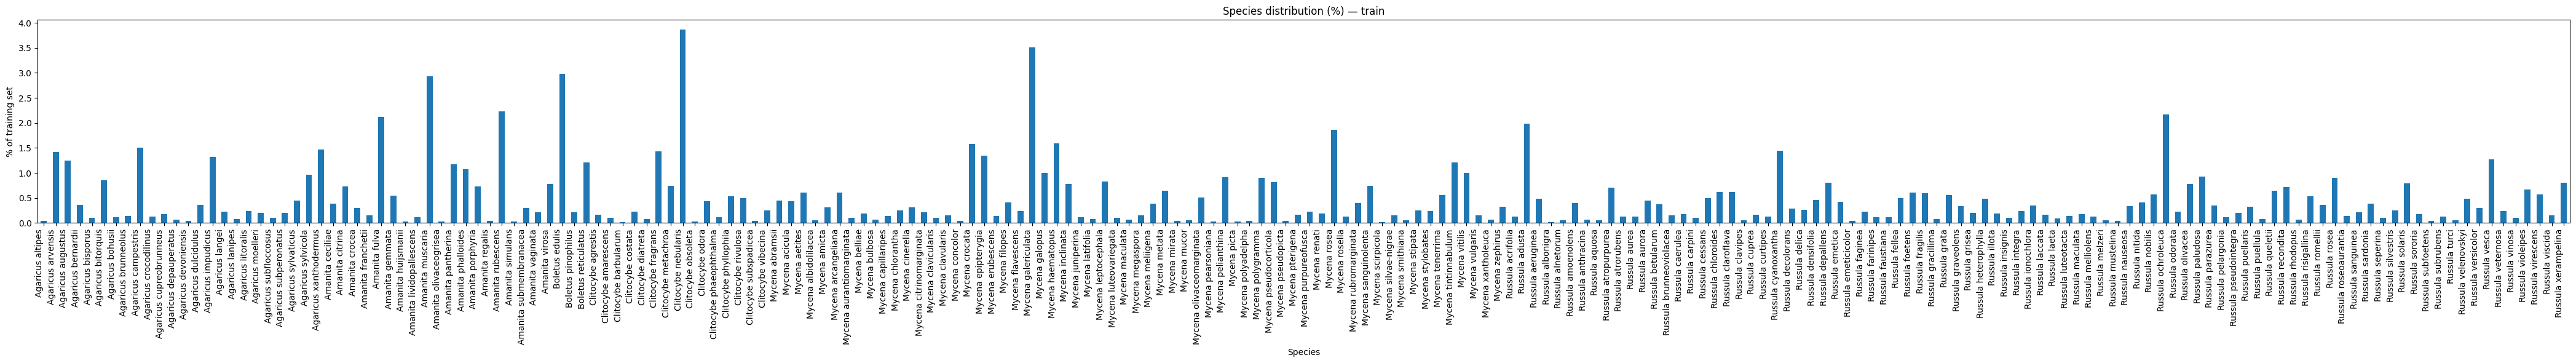

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# % distribution per species (0–100), sorted by species name (or use sort_values() for freq order)
pct = (train_df['species']
       .value_counts(normalize=True)
       .mul(100)
       .sort_index())

# Bar chart (vertical). Dynamic width so long label lists don’t squash.
plt.figure(figsize=(max(12, 0.2*len(pct)), 6))
pct.plot(kind='bar')
plt.ylabel('% of training set')
plt.xlabel('Species')
plt.title('Species distribution (%) — train')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

# (Optional) Save a copy
# plt.savefig('runs/eda/species_percent_distribution_train.png', dpi=200, bbox_inches='tight')
